# 1. Dataset Loading and Verification

In this section, we:

- Import the required libraries
- Load training, validation, and test datasets
- Verify image-label consistency
- Check for missing or corrupted images
- Analyze image dimensions and formats
- Identify duplicate entries

This step is important to ensure that the dataset is clean and reliable before performing exploratory data analysis and model training.

In [ ]:
# Install required packages

!pip install pandas numpy matplotlib seaborn pillow tqdm scipy

## 1.1 Import Libraries

The following libraries are used for:

- data handling,
- image processing,
- visualization,
- and dataset verification.

In [2]:
# Import required packages

import os
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

## 1.2 Define Dataset Paths

We define the paths for the training, validation, and testing datasets.

In [3]:
# Root dataset folder
DATASET_PATH = Path("dataset")

# Train paths
TRAIN_PATH = DATASET_PATH / "train"

# Validation paths
VALIDATE_PATH = DATASET_PATH / "valid"

# Test paths
TEST_PATH = DATASET_PATH / "test"

## 1.3 Load Label Files

Each dataset split contains a CSV file with image labels.

We load the CSV files into pandas DataFrames for analysis.

In [4]:
# Load CSV label files

train_df = pd.read_csv(TRAIN_PATH / "_classes.csv")
validate_df = pd.read_csv(VALIDATE_PATH / "_classes.csv")
test_df = pd.read_csv(TEST_PATH / "_classes.csv")

## 1.4 Preview Dataset

We inspect the first few rows of each dataset to understand the structure of the labels.

In [5]:
print("Train Dataset")
display(train_df.head())

print("\nValidation Dataset")
display(validate_df.head())

print("\nTest Dataset")
display(test_df.head())

Train Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,thinkwithgoogle_com_png.rf.0e3CasnPbMEGQSO8oMH...,1,1,1,0,1,0,1,1
1,urlzs_com_png.rf.0ea1b14c371dff348e9bba2948d8e...,1,0,0,0,1,0,0,1
2,amazon_com_png.rf.0oB8qzojBS2Tklffo69l.jpg,1,1,1,1,1,0,1,1
3,asahi_com_png.rf.120e05a147314b2805e7bad82dafc...,1,0,1,1,1,0,1,1
4,buymeacoffee_com_png.rf.0vBkaAYTkLI6YlTz5Gqu.jpg,1,1,1,0,1,0,0,1



Validation Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,tw_bid_yahoo_com_png.rf.00142efb44982bd766357c...,1,1,1,0,1,0,1,1
1,heavy_com_png.rf.02292a8559ef48759cdd54c775747...,1,1,1,0,1,0,1,1
2,buildyourfuture_withgoogle_com_png.rf.025d26dc...,1,0,1,0,1,0,1,1
3,crunchbase_com_png.rf.0269a6590355e6a198be21af...,0,0,1,0,1,0,1,1
4,radiolab_org_png.rf.045797115c9c28897a3ef9a34f...,1,0,1,1,1,0,1,1



Test Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,bbc_com_png.rf.01759781597857d451c44c7560e4e0b...,1,1,1,0,1,0,0,1
1,europarl_europa_eu_png.rf.0437dcc6989de06ee86c...,1,1,1,0,0,0,0,1
2,groups_yahoo_com_png.rf.06f3a1e8a3284cca2b1231...,1,1,1,0,1,0,1,1
3,wikihow_com_png.rf.06129667a4177043698b33e20e2...,1,1,1,0,1,0,1,1
4,shop_gopro_com_png.rf.08dff9eeeb81fc95d8f85eb4...,1,0,1,0,1,0,1,1


## 1.5 Check Dataset Shapes

We check the number of samples and label columns in each dataset split.

In [6]:
print("Train Shape:", train_df.shape)
print("Validation Shape:", validate_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1688, 9)
Validation Shape: (482, 9)
Test Shape: (242, 9)


## 1.6 Verify Missing Values

We check whether the dataset contains missing values in any column.

In [7]:
print("Missing values in training set:")
display(train_df.isnull().sum())

print("\nMissing values in validation set:")
display(validate_df.isnull().sum())

print("\nMissing values in test set:")
display(test_df.isnull().sum())

Missing values in training set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64


Missing values in validation set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64


Missing values in test set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64

## 1.7 Check Duplicate Entries

Duplicate entries may negatively affect model training and evaluation.

We check for duplicate rows in each dataset.

In [8]:
print("Duplicate rows in training set:", train_df.duplicated().sum())
print("Duplicate rows in validation set:", validate_df.duplicated().sum())
print("Duplicate rows in test set:", test_df.duplicated().sum())

Duplicate rows in training set: 0
Duplicate rows in validation set: 0
Duplicate rows in test set: 0


## 1.8 Verify Image Existence

We verify that every image listed in the CSV files actually exists inside the dataset folders.

In [9]:
IMAGE_COLUMN = "filename"


def check_missing_images(df, folder_path):
    
    missing_images = []

    for image_name in df[IMAGE_COLUMN]:

        image_path = folder_path / image_name

        if not image_path.exists():
            missing_images.append(image_name)

    return missing_images

In [10]:
train_missing = check_missing_images(train_df, TRAIN_PATH)
validate_missing = check_missing_images(validate_df, VALIDATE_PATH)
test_missing = check_missing_images(test_df, TEST_PATH)

print("Missing train images:", len(train_missing))
print("Missing validation images:", len(validate_missing))
print("Missing test images:", len(test_missing))

Missing train images: 0
Missing validation images: 0
Missing test images: 0


## 1.9 Verify Corrupted Images

We attempt to open every image to identify corrupted or unreadable files.

In [11]:
def check_corrupted_images(df, folder_path):

    corrupted = []

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:
            img = Image.open(image_path)
            img.verify()

        except Exception:
            corrupted.append(image_name)

    return corrupted

In [12]:
train_corrupted = check_corrupted_images(train_df, TRAIN_PATH)
test_corrupted = check_corrupted_images(test_df, TEST_PATH)
valid_corrupted = check_corrupted_images(validate_df, VALIDATE_PATH)

print("Corrupted training images:", len(train_corrupted))
print("Corrupted testing images:", len(test_corrupted))
print("Corrupted validation images:", len(valid_corrupted))

100%|███████████████████████████████████████████████████████████████████████████████| 482/482 [00:00<00:00, 5700.16it/s]

Corrupted training images: 0
Corrupted testing images: 0
Corrupted validation images: 0


## 1.10 Analyze Image Dimensions

We will verify the image widths and heights to see if there are images with different resolutions in the dataset.

In [13]:
def extract_image_sizes(df, folder_path):

    widths = []
    heights = []

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:
            img = Image.open(image_path)

            width, height = img.size

            widths.append(width)
            heights.append(height)

        except:
            pass

    return widths, heights

In [14]:
train_widths, train_heights = extract_image_sizes(train_df, TRAIN_PATH)

100%|████████████████████████████████████████████████████████████████████████████| 1688/1688 [00:00<00:00, 14500.50it/s]


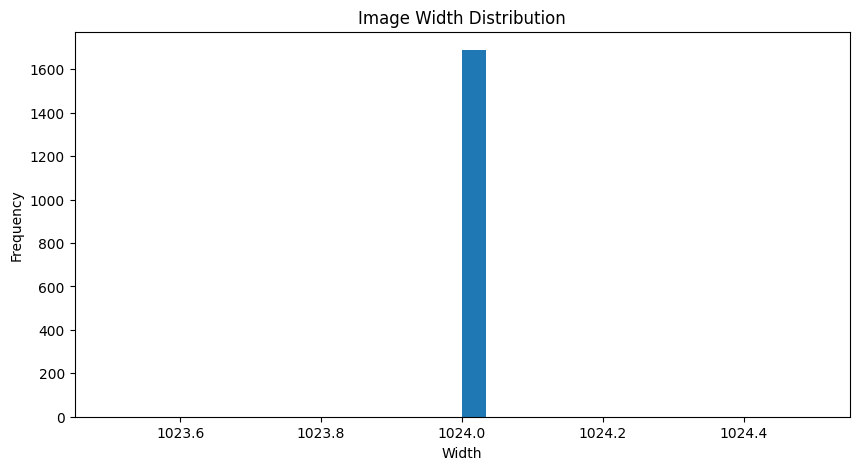

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(train_widths, bins=30)

plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

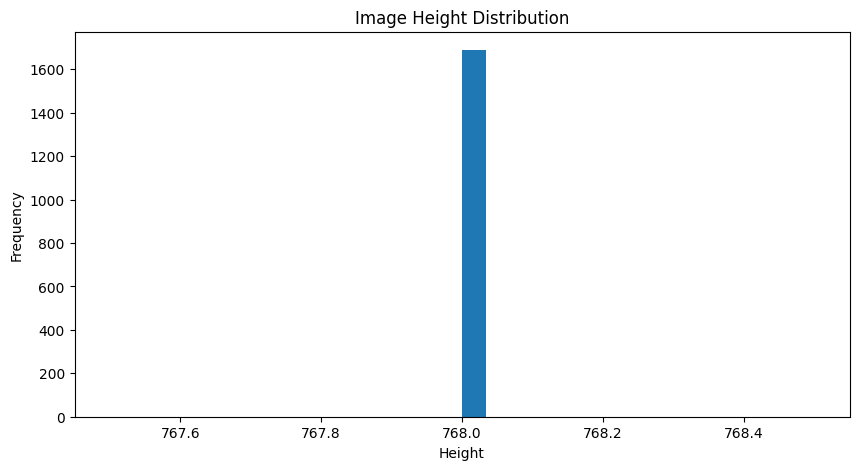

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(train_heights, bins=30)

plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

## 1.11 Analyze Image Aspect Ratios

Different webpage screenshots may have highly variable aspect ratios.

This analysis helps determine whether resizing or padding strategies will be required during preprocessing.

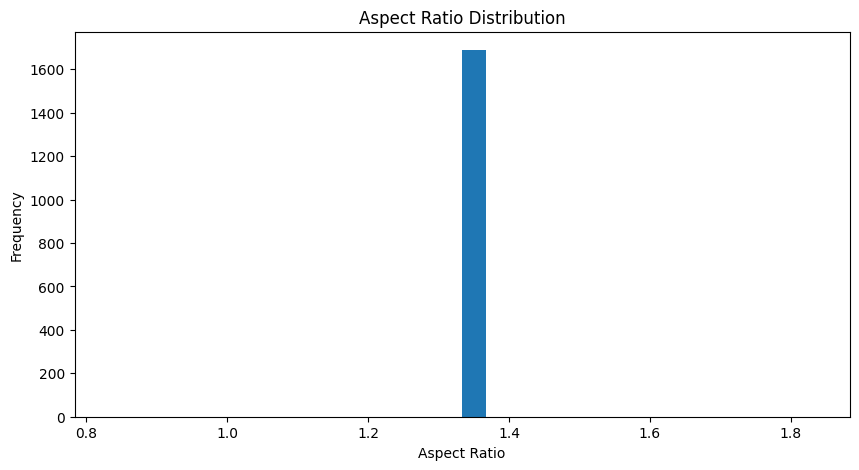

In [17]:
aspect_ratios = np.array(train_widths) / np.array(train_heights)

plt.figure(figsize=(10, 5))

plt.hist(aspect_ratios, bins=30)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")

plt.show()

The resolution analysis shows that all webpage screenshots share a consistent image size and aspect ratio. This indicates that the dataset was preprocessed in a standardized manner before distribution.

The absence of resolution variability simplifies the preprocessing pipeline since additional resizing or aspect-ratio correction strategies are not required during model training.

## 1.12 Summary of Dataset Verification

At this stage, we have:

- Loaded all dataset splits
- Verified dataset integrity
- Checked for missing values and duplicates
- Verified image existence
- Identified corrupted files
- Analyzed image resolution distributions
- Examined aspect ratio variability

These checks ensure that the dataset is clean and suitable for further exploratory data analysis and preprocessing.

# 2. Label Exploratory Data Analysis

In this section, we analyze the label structure of the dataset.

Since this is a multi-label classification problem, each image may contain multiple labels simultaneously. Understanding the label distribution and relationships between labels is important for:

- identifying class imbalance,
- understanding label sparsity,
- analyzing label dependencies,
- and preparing the dataset for model training.

The following analyses are performed:

- Class frequency analysis
- Label cardinality analysis
- Label density analysis
- Label co-occurrence analysis
- Correlation analysis between labels
- Statistical analysis of label distributions

## 2.1 Extract Label Columns

The dataset contains one column for image filenames and multiple columns representing labels.

We separate the label columns for analysis.

In [18]:
# Remove image filename column

label_columns = train_df.columns.drop(IMAGE_COLUMN)

print("Label Columns:")
print(label_columns.tolist())

Label Columns:
[' button', ' field', ' heading', ' iframe', ' image', ' label', ' link', ' text']


## 2.2 Class Frequency Analysis

We calculate the number of positive samples for each label.

This analysis helps identify:

- class imbalance,
- dominant labels,
- and rare classes.

In [19]:
# Count positive samples for each class

class_counts = train_df[label_columns].sum().sort_values(ascending=False)

print("Total training samples:", len(train_df))

print("\nClass Distribution:\n")
print(class_counts)

print("\nSmallest Class:")
print(class_counts.idxmin(), "->", class_counts.min())

print("\nLargest Class:")
print(class_counts.idxmax(), "->", class_counts.max())

Total training samples: 1688

Class Distribution:

text       1648
image      1630
button     1616
heading    1492
link       1306
field       806
iframe      436
label        98
dtype: int64

Smallest Class:
 label -> 98

Largest Class:
 text -> 1648


## 2.3 Visualize Class Distribution

We visualize the frequency of each label to better understand the imbalance between classes.

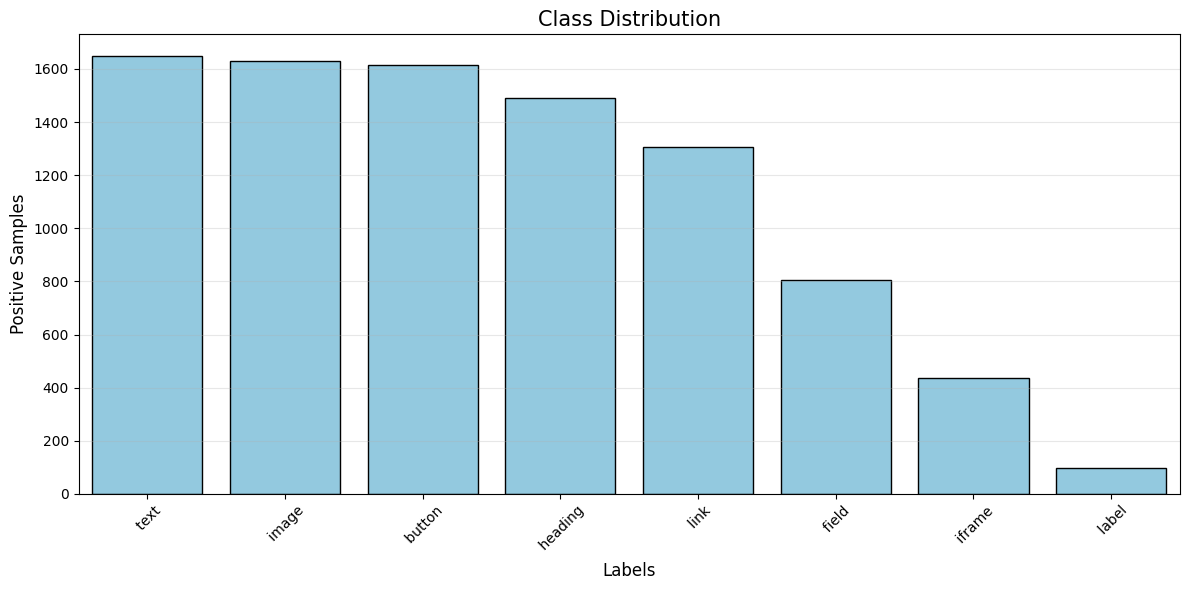

In [20]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    color="skyblue",
    edgecolor="black"
)

plt.title("Class Distribution", fontsize=15)
plt.xlabel("Labels", fontsize=12)
plt.ylabel("Positive Samples", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 2.4 Imbalance Ratio Analysis

We calculate the imbalance ratio between the largest and smallest classes.

A large imbalance ratio may indicate that certain labels are significantly underrepresented, which can negatively affect model learning and evaluation.

In [21]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest Class Size :", largest_class)
print("Smallest Class Size:", smallest_class)

print("\nImbalance Ratio:", round(imbalance_ratio, 2))

Largest Class Size : 1648
Smallest Class Size: 98

Imbalance Ratio: 16.82


## 2.5 Label Cardinality Analysis

In multi-label classification, label cardinality refers to the average number of labels assigned per image.

This helps us understand how complex each sample is in terms of annotation density.

A higher cardinality indicates that images tend to contain multiple UI components simultaneously, while a lower value suggests more isolated object presence.

In [22]:
# Compute number of labels per image

labels_per_image = train_df[label_columns].sum(axis=1)

# Summary statistics
print("Label Cardinality (per image):")
print(labels_per_image.describe())

Label Cardinality (per image):
count    1688.000000
mean        5.350711
std         1.002776
min         2.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         8.000000
dtype: float64


In [24]:
# Temporary

print("Mean labels per image:", labels_per_image.mean())
print("Median labels per image:", labels_per_image.median())
print("Max labels in one image:", labels_per_image.max())
print("Min labels in one image:", labels_per_image.min())

Mean labels per image: 5.350710900473934
Median labels per image: 5.0
Max labels in one image: 8
Min labels in one image: 2


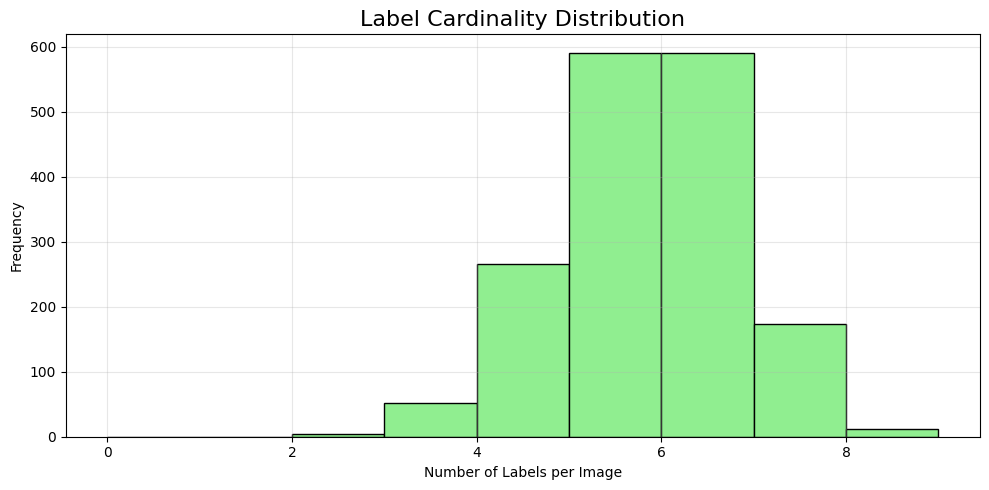

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    labels_per_image,
    bins=range(int(labels_per_image.max()) + 2),
    color="lightgreen",
    edgecolor="black"
)

plt.title("Label Cardinality Distribution", fontsize=16)
plt.xlabel("Number of Labels per Image")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()